In [33]:
import os
import re
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import tkinter as tk
from tkinter import filedialog, simpledialog

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, total=None, desc=None, **kwargs):
        if total is None:
            try:
                total = len(iterable)
            except TypeError:
                total = None
        prefijo = f"{desc}: " if desc else ""
        for i, item in enumerate(iterable, start=1):
            yield item
            if total:
                pct = 100 * i / total
                print(f"\r{prefijo}{pct:5.1f}% ({i}/{total})", end="", flush=True)
        if total:
            print()

# Parámetros Bootstrap
N_BOOTSTRAP_INCERTIDUMBRE = 50
BOOTSTRAP_GRID_RES = 60j

def _calcular_limites_criticos(Z: np.ndarray, X: np.ndarray, umbral_minimo: float):
    """
    Extrae la distancia óptima y el límite máximo (borde del contorno) 
    basándose estrictamente en el umbral visual de la densidad.
    """
    Z_flat = Z.flatten()
    
    # 1. Distancia Óptima (Pico)
    idx_max = np.argmax(Z_flat)
    pico_log = X.flatten()[idx_max]
    
    # 2. Límite basado en el Contorno de Densidad
    indices_alta_densidad = np.where(Z >= umbral_minimo)
    x_alta_densidad = X[indices_alta_densidad]
    
    if len(x_alta_densidad) == 0:
        return None, None
        
    max_log = float(np.max(x_alta_densidad))
    
    return pico_log, max_log


def _bootstrap_limites_criticos(x, y, weights, xlims, ylims, umbral_minimo, n_bootstrap=N_BOOTSTRAP_INCERTIDUMBRE, grid_res=BOOTSTRAP_GRID_RES):
    """
    Simula fluctuaciones del KDE para encontrar el error en el límite del contorno,
    aplicando el mismo umbral estático de la densidad original para evitar outliers.
    """
    rng = np.random.default_rng()
    n = len(x)
    pico_boot_log, max_boot_log = [], []

    Xb, Yb = np.mgrid[xlims[0]:xlims[1]:grid_res, ylims[0]:ylims[1]:grid_res]
    positions_b = np.vstack([Xb.ravel(), Yb.ravel()])

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        x_b, y_b, w_b = x[idx], y[idx], weights[idx]

        if x_b.var() == 0 or y_b.var() == 0:
            continue
        try:
            kde_b = gaussian_kde(np.vstack([x_b, y_b]), weights=w_b, bw_method=0.6)
            Z_b = np.reshape(kde_b(positions_b).T, Xb.shape)
        except np.linalg.LinAlgError:
            continue

        pico_l, max_l = _calcular_limites_criticos(Z_b, Xb, umbral_minimo)
        if pico_l is not None:
            pico_boot_log.append(pico_l)
            max_boot_log.append(max_l)

    return pico_boot_log, max_boot_log


def _dibujar_panel_kde2d_hibrido(fig, ax, df_subset, titulo, estilos_sistema, xlims, ylims, es_primer_panel=False):
    resumen_panel = None
    
    if df_subset.empty:
        ax.set_title(f"{titulo}\n(N=0)", fontsize=16, fontweight="bold", pad=15)
        ax.axis("off")
        return resumen_panel

    mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
    df_valid = df_subset[mask_valid].copy()

    if df_valid.empty:
        ax.set_title(f"{titulo}\n(N=0 válidos)", fontsize=16, fontweight="bold", pad=15)
        ax.axis("off")
        return resumen_panel

    n_planetas = len(df_valid)

    metricas_info = [
        ("Area_Estable_km2", "Stable Zones", "blue", "fill_and_line"),
        ("Area_Inestable", "Unstable Zones", "orange", "line_only"),
        ("Zonas Colisión m1", "Collision m1 (Star)", "red", "line_only"),
        ("Area_Colision_m2", "Collision m2 (Planet)", "green", "line_only"),
    ]

    for metrica, label_str, color_principal, plot_type in metricas_info:
        if metrica not in df_valid.columns: 
            continue
            
        mask_metrica = df_valid[metrica] > 0
        df_metrica = df_valid[mask_metrica]
        
        if len(df_metrica) >= 4:
            x_m = np.log10(df_metrica["Distancia_UA"].values)
            y_m = np.log10(df_metrica["Masa_Tierra"].values)
            weights = _safe_log10(df_metrica[metrica].values)
            
            if x_m.var() > 0 and y_m.var() > 0 and np.sum(weights) > 0:
                try:
                    xy = np.vstack([x_m, y_m])
                    kde = gaussian_kde(xy, weights=weights, bw_method=0.6)

                    X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
                    positions = np.vstack([X.ravel(), Y.ravel()])
                    Z = np.reshape(kde(positions).T, X.shape)
                    Z_flat = Z.flatten()

                    min_val = max(np.percentile(Z_flat, 40), Z_flat.max() * 0.1)
                    max_val = np.percentile(Z_flat, 95)
                    
                    if max_val > min_val:
                        niveles = np.linspace(min_val, max_val, 4)
                        umbral_minimo = niveles[0] # El límite inferior exacto que será visible
                        
                        if plot_type == "fill_and_line":
                            ax.contourf(X, Y, Z, levels=niveles, cmap="Blues", extend='max', alpha=0.5, zorder=1)
                            ax.contour(X, Y, Z, levels=niveles, colors=[color_principal], linewidths=2, zorder=2)
                        else:
                            ax.contour(X, Y, Z, levels=niveles, colors=[color_principal], linewidths=2.5, zorder=2)

                    # ====== EXTRACCIÓN Y GRAFICADO DE MÉTRICAS (Basado en el Contorno Visible) ======
                    if metrica == "Area_Estable_km2" and max_val > min_val:
                        pico_log, max_log = _calcular_limites_criticos(Z, X, umbral_minimo)
                        
                        if pico_log is not None:
                            pico_au = 10 ** pico_log
                            max_au = 10 ** max_log
                            
                            # Bootstrap evaluando las deformaciones del contorno, sin outliers
                            pico_boot_log, max_boot_log = _bootstrap_limites_criticos(x_m, y_m, weights, xlims, ylims, umbral_minimo)
                            
                            if len(pico_boot_log) >= 5:
                                # Convertir distribuciones a AU reales antes de calcular dispersión
                                pico_boot_au = 10 ** np.array(pico_boot_log)
                                max_boot_au = 10 ** np.array(max_boot_log)
                                
                                # Percentiles 16 y 84 simulan 1 sigma robusto
                                p16_pico, p84_pico = np.percentile(pico_boot_au, 16), np.percentile(pico_boot_au, 84)
                                p16_max, p84_max = np.percentile(max_boot_au, 16), np.percentile(max_boot_au, 84)
                                
                                sigma_pico_au = (p84_pico - p16_pico) / 2.0
                                sigma_max_au = (p84_max - p16_max) / 2.0
                            else:
                                sigma_pico_au = 0.0
                                sigma_max_au = 0.0
                                
                            resumen_panel = {
                                "titulo": titulo,
                                "opt_au": pico_au, "opt_err": sigma_pico_au,
                                "max_au": max_au, "max_err": sigma_max_au
                            }
                            
                            if sigma_max_au > 0:
                                texto_opt = f"Opt: {pico_au:.2f} $\\pm$ {sigma_pico_au:.2f} AU"
                                texto_max = f"Max: {max_au:.2f} $\\pm$ {sigma_max_au:.2f} AU"
                            else:
                                texto_opt = f"Opt: {pico_au:.2f} AU"
                                texto_max = f"Max: {max_au:.2f} AU"
                            
                            rango_y = ylims[1] - ylims[0]
                            rango_x = xlims[1] - xlims[0]
                            offset = rango_x * 0.015
                            
                            ha_pico = "left" if pico_log < (xlims[0]+xlims[1])/2 else "right"
                            ha_max = "left" if max_log < (xlims[0]+xlims[1])/2 else "right"
                            offset_pico = offset if ha_pico == "left" else -offset
                            offset_max = offset if ha_max == "left" else -offset
                            
                            # Líneas Verticales Informativas
                            ax.axvline(x=pico_log, color="gold", linestyle="--", linewidth=2.5, zorder=6)
                            ax.axvline(x=max_log, color="crimson", linestyle="-.", linewidth=2.5, zorder=6, alpha=0.95)
                            
                            # Cajas de Texto de las métricas
                            ax.text(pico_log + offset_pico, ylims[1] - rango_y * 0.05, texto_opt,
                                    color="black", fontsize=11, fontweight="bold", zorder=7, ha=ha_pico, va="top",
                                    bbox=dict(facecolor="gold", alpha=0.9, edgecolor="gray", boxstyle="round,pad=0.3"))
                            
                            ax.text(max_log + offset_max, ylims[1] - rango_y * 0.15, texto_max,
                                    color="white", fontsize=11, fontweight="bold", zorder=7, ha=ha_max, va="top",
                                    bbox=dict(facecolor="crimson", alpha=0.9, edgecolor="gray", boxstyle="round,pad=0.3"))

                except np.linalg.LinAlgError:
                    pass

    # Graficar puntos de los planetas reales 
    for sist in df_valid["Sistema"].unique():
        df_sist = df_valid[df_valid["Sistema"] == sist]
        props = estilos_sistema.get(sist, {"marker": "o", "color": "white"})
        ax.scatter(np.log10(df_sist["Distancia_UA"]),
                   np.log10(df_sist["Masa_Tierra"]),
                   marker=props["marker"], color=props["color"],
                   s=110, edgecolor="white", linewidth=1.0,
                   label=sist, zorder=3)
    
    # Marcadores Astronómicos
    ax.scatter(0, 0, marker='o', s=300, color='dodgerblue', edgecolor='white', linewidth=1.5, label="Earth", zorder=4, clip_on=False)
    ax.text(0, -0.15, "Earth", ha='center', va='top', fontsize=12, fontweight='bold', color='dodgerblue', zorder=4)

    log_dist_jup = np.log10(5.2)
    log_mass_jup = np.log10(318.0)
    ax.scatter(log_dist_jup, log_mass_jup, marker='o', s=450, color='peru', edgecolor='white', linewidth=1.5, label="Jupiter", zorder=4, clip_on=False)
    ax.text(log_dist_jup, log_mass_jup - 0.15, "Jupiter", ha='center', va='top', fontsize=12, fontweight='bold', color='peru', zorder=4)

    ax.set_title(f"{titulo}\n(N={n_planetas} planetas)", fontsize=18, fontweight="bold", pad=15)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_box_aspect(1) 
    
    ax.set_xlabel("log[Distance] (AU)", fontsize=16) 
    if es_primer_panel:
        ax.set_ylabel(r"log[Planetary Mass] ($M_\oplus$)", fontsize=16)
    
    ax.grid(True, which="both", ls="--", color="gray", alpha=0.3, zorder=0)

    return resumen_panel

def plot_islands_kde2d_combinado(df: pd.DataFrame, base_dir: str, tipos=("F", "G", "K", "M")):
    print(f"\nGenerando Mapas de Contornos 2D KDE Híbridos y Análisis Estadístico...")
    df = df.copy()
    if "Sistema" not in df.columns:
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
    
    df["Tipo_Estrella"] = df["Tipo_Estrella"].astype(str).str.upper().str.strip()
    estilos_sistema = _asignar_estilos_sistema(df)
    
    dist_pos = df["Distancia_UA"][df["Distancia_UA"] > 0]
    masa_pos = df["Masa_Tierra"][df["Masa_Tierra"] > 0]
    
    if dist_pos.empty or masa_pos.empty:
        print("No hay datos válidos para graficar.")
        return
    x_all = np.log10(dist_pos.values)
    y_all = np.log10(masa_pos.values)
    
    margen_x = (x_all.max() - x_all.min()) * 0.1
    xlims = (x_all.min() - margen_x, x_all.max() + margen_x)
    min_y_req = min(y_all.min() - 0.4, -0.5)
    max_y_req = max(y_all.max() + 0.4, 2.8)
    ylims = (min_y_req, max_y_req)
    num_paneles = len(tipos)
    
    fig, axes = plt.subplots(1, num_paneles, figsize=(7 * num_paneles, 12))
    fig.subplots_adjust(bottom=0.35, wspace=0.15)
    fig.suptitle("2D KDE Contour Maps by Stellar Type", fontsize=28, fontweight="bold")
    if num_paneles == 1:
        axes = [axes]
    tareas_paneles = [
        (axes[i], df[df["Tipo_Estrella"] == tipo].copy(), f"Type {tipo}")
        for i, tipo in enumerate(tipos)
    ]
    resumenes = []
    for ax, df_subset, titulo in tqdm(tareas_paneles, desc="Generando paneles 2D híbridos", unit="panel"):
        res = _dibujar_panel_kde2d_hibrido(fig, ax, df_subset, titulo, estilos_sistema, xlims, ylims, es_primer_panel=(ax is axes[0]))
        if res:
            resumenes.append(res)
    # Imprimir en la Consola ANTES de mostrar el gráfico
    print("\n" + "="*95)
    print("🎯 RESUMEN DE PROBABILIDAD ORBITAL (Zonas Estables)")
    print("="*95)
    for res in resumenes:
        nombre_estrella = res["titulo"].replace("Type", "Estrella Tipo")
        print(f"{nombre_estrella} -> Distancia Óptima (Máx. Probabilidad): {res['opt_au']:6.2f} ± {res['opt_err']:.2f} AU | Límite Máximo del Contorno: {res['max_au']:6.2f} ± {res['max_err']:.2f} AU")
    print("="*95 + "\n")
    handles_global = []
    labels_global = []
    
    leyenda_base = [
        ("Stable Zones", "blue", "fill_and_line"),
        ("Unstable Zones", "orange", "line_only"),
        ("Collision m1 (Star)", "red", "line_only"),
        ("Collision m2 (Planet)", "green", "line_only"),
    ]
    
    for label, color, plot_type in leyenda_base:
        if plot_type == "fill_and_line":
            patch = mpatches.Patch(facecolor=plt.get_cmap("Blues")(0.5), edgecolor=color, linewidth=2, label=label)
            handles_global.append(patch)
        else:
            line = Line2D([0], [0], color=color, linewidth=2.5, label=label)
            handles_global.append(line)
        labels_global.append(label)
    
    for ax in axes:
        h_ax, l_ax = ax.get_legend_handles_labels()
        for h, l in zip(h_ax, l_ax):
            if l not in labels_global:
                labels_global.append(l)
                handles_global.append(h)
    
    if labels_global:
        fig.legend(handles_global, labels_global, loc="upper center", bbox_to_anchor=(0.5, 0.25),
                   ncol=min(8, len(labels_global)), frameon=True, shadow=True, fontsize=11, title="Global Legend", title_fontsize=14)
    ruta_pdf = os.path.join(base_dir, f"Map_2D_KDE_Hybrid_PorTipoEstrella.pdf")
    plt.savefig(ruta_pdf, format="pdf", dpi=300, bbox_inches="tight")
    
    print(f"\nGráfico vectorial guardado exitosamente en: {ruta_pdf}")
    plt.show()
    plt.close(fig)



Esperando selección de carpetas en las ventanas emergentes...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F (Tipo F)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_G (Tipo G)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_K (Tipo K)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M (Tipo M)...
✅ Lectura completada. Se extrajeron datos de 448 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Se graficarán 448 planetas (sistemas de >= 3 planetas).

Generando Mapas de Contornos 2D KDE Híbridos y Análisis Estadístico...


Generando paneles 2D híbridos: 100%|██████████| 4/4 [00:04<00:00,  1.21s/panel]



🎯 RESUMEN DE PROBABILIDAD ORBITAL (Zonas Estables)
Estrella Tipo F -> Distancia Óptima (Máx. Probabilidad):   0.10 ± 0.02 AU | Límite Máximo del Contorno:   2.44 ± 0.90 AU
Estrella Tipo G -> Distancia Óptima (Máx. Probabilidad):   0.14 ± 0.02 AU | Límite Máximo del Contorno:   8.77 ± 4.03 AU
Estrella Tipo K -> Distancia Óptima (Máx. Probabilidad):   0.11 ± 0.01 AU | Límite Máximo del Contorno:   4.49 ± 1.74 AU
Estrella Tipo M -> Distancia Óptima (Máx. Probabilidad):   0.07 ± 0.01 AU | Límite Máximo del Contorno:   0.68 ± 0.11 AU


Gráfico vectorial guardado exitosamente en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F\Map_2D_KDE_Hybrid_PorTipoEstrella.pdf


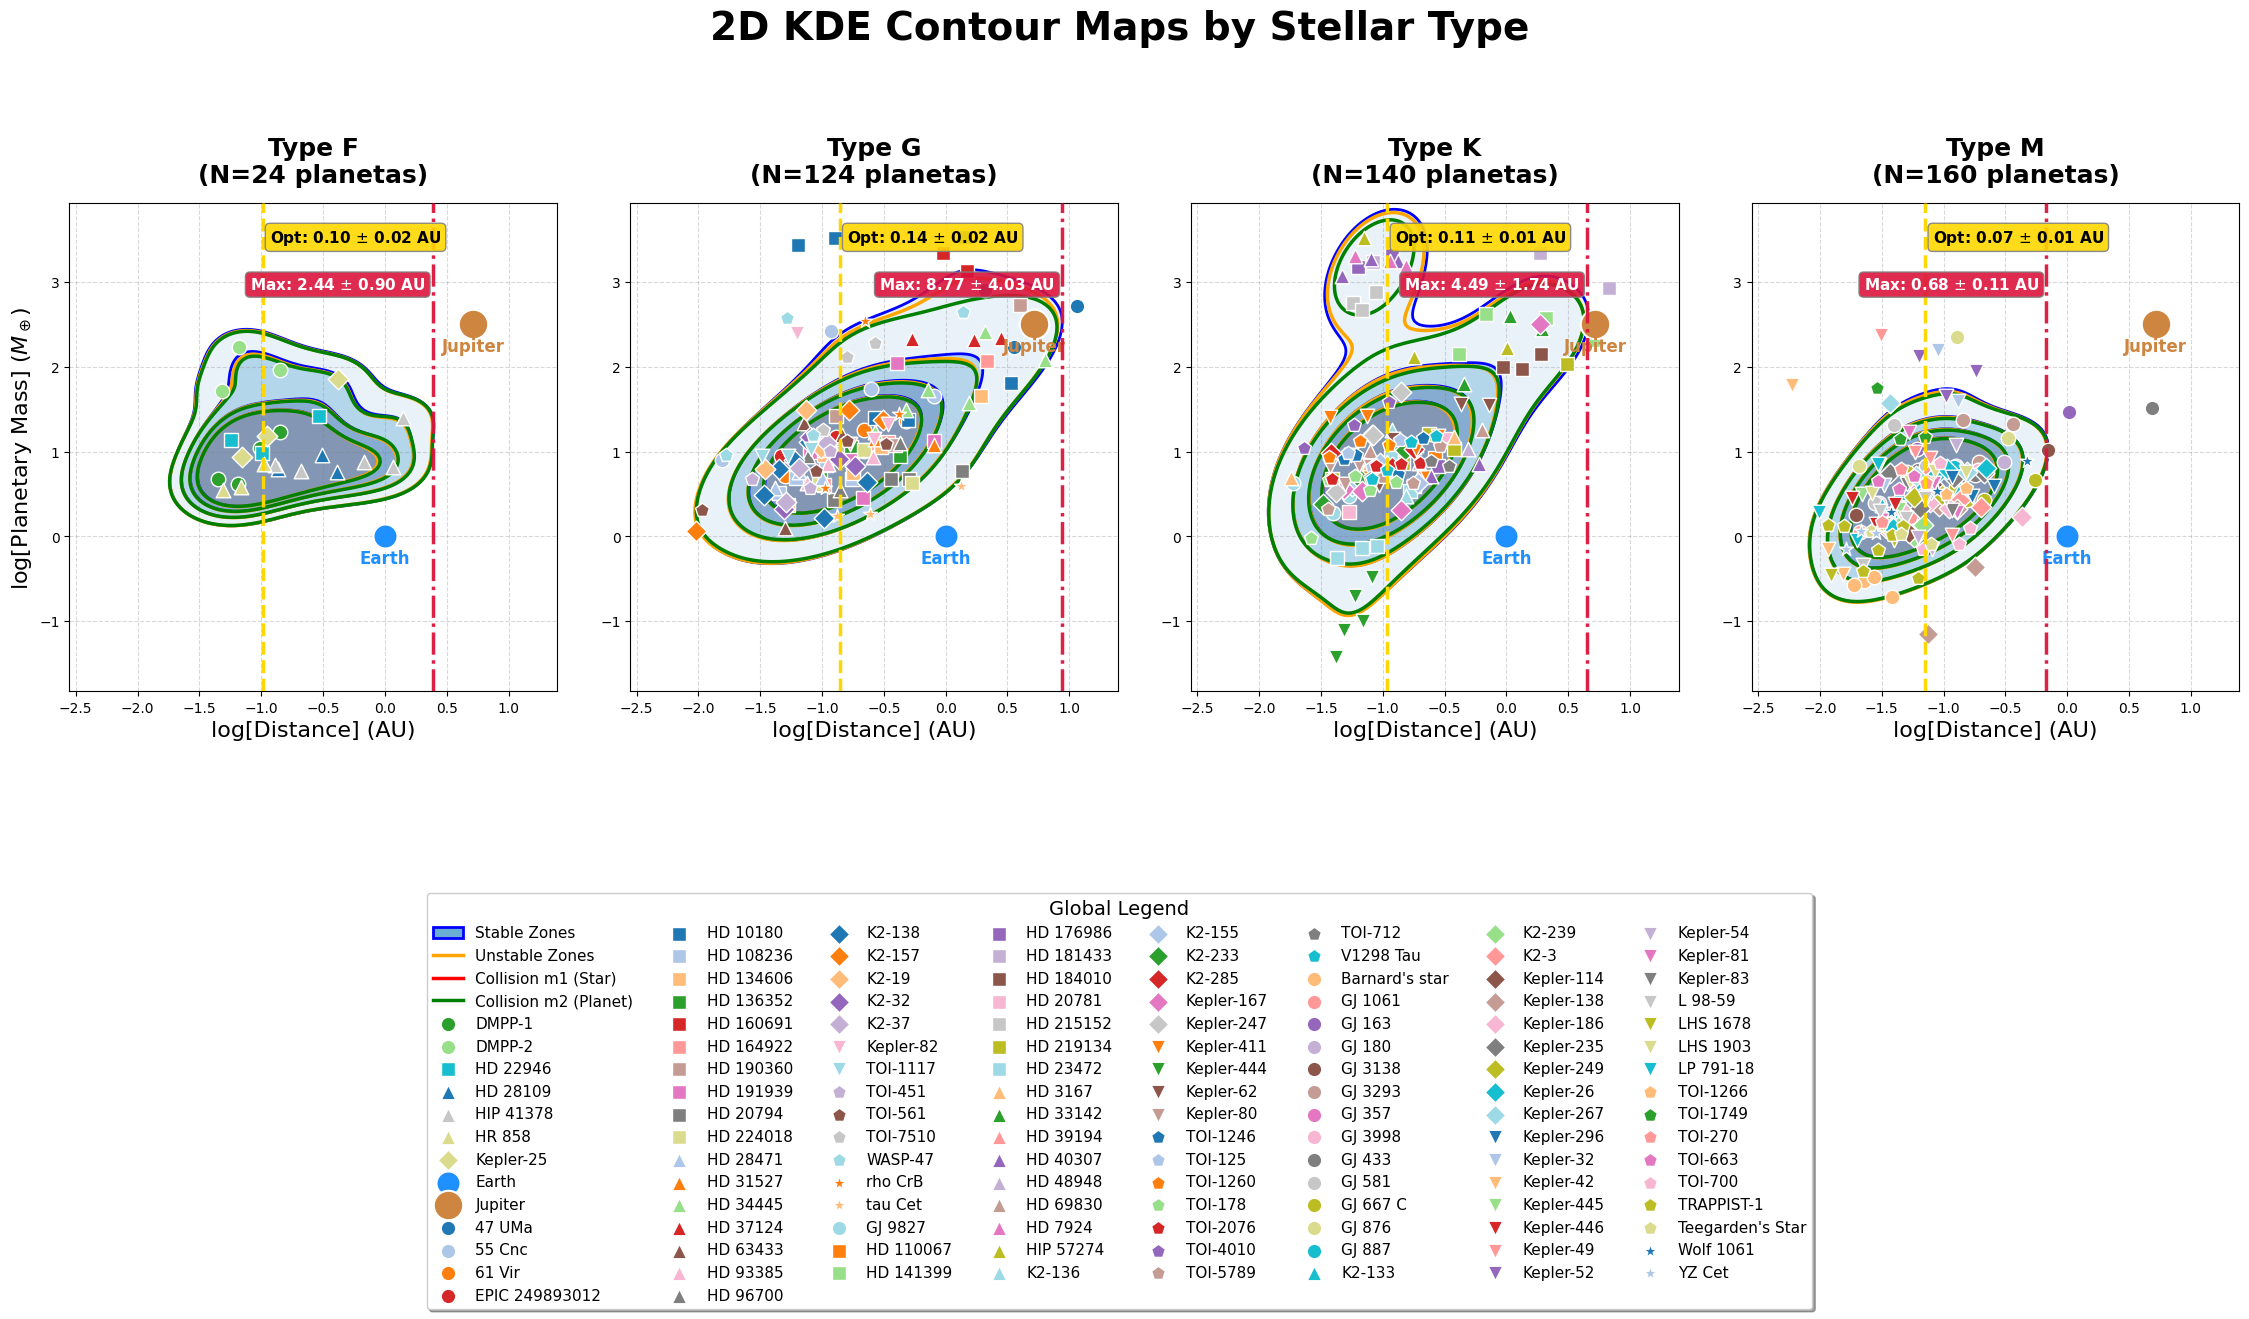


✅ Generación híbrida completada con éxito. Archivos ubicados en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F


In [34]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    print("Esperando selección de carpetas en las ventanas emergentes...")
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
    if not df_datos.empty:
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
        if not df_filtrado.empty:
            print(f"\nSe graficarán {len(df_filtrado)} planetas (sistemas de >= 3 planetas).")
            plot_islands_kde2d_combinado(df_filtrado, DIRECTORIO_RAIZ)
            print("\n✅ Generación híbrida completada con éxito. Archivos ubicados en:", DIRECTORIO_RAIZ)
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")



In [41]:
def _dibujar_panel_kde2d_hibrido(fig, ax, df_subset, titulo, estilos_sistema, xlims, ylims, es_primer_panel=False):
    resumen_panel = None
    
    if df_subset.empty:
        ax.set_title(f"{titulo}\n(N=0 systems)", fontsize=16, fontweight="bold", pad=15)
        ax.axis("off")
        return resumen_panel

    mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
    df_valid = df_subset[mask_valid].copy()

    if df_valid.empty:
        ax.set_title(f"{titulo}\n(N=0 valid systems)", fontsize=16, fontweight="bold", pad=15)
        ax.axis("off")
        return resumen_panel

    # CAMBIO AQUÍ: Contamos la cantidad de SISTEMAS únicos en lugar de planetas
    n_sistemas = df_valid["Sistema"].nunique()

    metricas_info = [
        ("Area_Estable_km2", "Stable Zones", "blue", "fill_and_line"),
        ("Area_Inestable", "Unstable Zones", "orange", "line_only"),
        ("Zonas Colisión m1", "Collision m1 (Star)", "red", "line_only"),
        ("Area_Colision_m2", "Collision m2 (Planet)", "green", "line_only"),
    ]

    for metrica, label_str, color_principal, plot_type in metricas_info:
        if metrica not in df_valid.columns: 
            continue
            
        mask_metrica = df_valid[metrica] > 0
        df_metrica = df_valid[mask_metrica]
        
        if len(df_metrica) >= 4:
            x_m = np.log10(df_metrica["Distancia_UA"].values)
            y_m = np.log10(df_metrica["Masa_Tierra"].values)
            weights = _safe_log10(df_metrica[metrica].values)
            
            if x_m.var() > 0 and y_m.var() > 0 and np.sum(weights) > 0:
                try:
                    xy = np.vstack([x_m, y_m])
                    kde = gaussian_kde(xy, weights=weights, bw_method=0.6)

                    X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
                    positions = np.vstack([X.ravel(), Y.ravel()])
                    Z = np.reshape(kde(positions).T, X.shape)
                    Z_flat = Z.flatten()

                    min_val = max(np.percentile(Z_flat, 40), Z_flat.max() * 0.1)
                    max_val = np.percentile(Z_flat, 95)
                    
                    if max_val > min_val:
                        niveles = np.linspace(min_val, max_val, 4)
                        umbral_minimo = niveles[0] # El límite inferior exacto que será visible
                        
                        if plot_type == "fill_and_line":
                            ax.contourf(X, Y, Z, levels=niveles, cmap="Blues", extend='max', alpha=0.5, zorder=1)
                            ax.contour(X, Y, Z, levels=niveles, colors=[color_principal], linewidths=2, zorder=2)
                        else:
                            ax.contour(X, Y, Z, levels=niveles, colors=[color_principal], linewidths=2.5, zorder=2)

                    # ====== EXTRACCIÓN Y GRAFICADO DE MÉTRICAS (Basado en el Contorno Visible) ======
                    if metrica == "Area_Estable_km2" and max_val > min_val:
                        pico_log, max_log = _calcular_limites_criticos(Z, X, umbral_minimo)
                        
                        if pico_log is not None:
                            pico_au = 10 ** pico_log
                            max_au = 10 ** max_log
                            
                            # Bootstrap evaluando las deformaciones del contorno, sin outliers
                            pico_boot_log, max_boot_log = _bootstrap_limites_criticos(x_m, y_m, weights, xlims, ylims, umbral_minimo)
                            
                            if len(pico_boot_log) >= 5:
                                # Convertir distribuciones a AU reales antes de calcular dispersión
                                pico_boot_au = 10 ** np.array(pico_boot_log)
                                max_boot_au = 10 ** np.array(max_boot_log)
                                
                                # Percentiles 16 y 84 simulan 1 sigma robusto
                                p16_pico, p84_pico = np.percentile(pico_boot_au, 16), np.percentile(pico_boot_au, 84)
                                p16_max, p84_max = np.percentile(max_boot_au, 16), np.percentile(max_boot_au, 84)
                                
                                sigma_pico_au = (p84_pico - p16_pico) / 2.0
                                sigma_max_au = (p84_max - p16_max) / 2.0
                            else:
                                sigma_pico_au = 0.0
                                sigma_max_au = 0.0
                                
                            resumen_panel = {
                                "titulo": titulo,
                                "opt_au": pico_au, "opt_err": sigma_pico_au,
                                "max_au": max_au, "max_err": sigma_max_au
                            }
                            
                            if sigma_max_au > 0:
                                texto_opt = f"Opt: {pico_au:.2f} $\\pm$ {sigma_pico_au:.2f} AU"
                                texto_max = f"Max: {max_au:.2f} $\\pm$ {sigma_max_au:.2f} AU"
                            else:
                                texto_opt = f"Opt: {pico_au:.2f} AU"
                                texto_max = f"Max: {max_au:.2f} AU"
                            
                            rango_y = ylims[1] - ylims[0]
                            rango_x = xlims[1] - xlims[0]
                            offset = rango_x * 0.015
                            
                            ha_pico = "left" if pico_log < (xlims[0]+xlims[1])/2 else "right"
                            ha_max = "left" if max_log < (xlims[0]+xlims[1])/2 else "right"
                            offset_pico = offset if ha_pico == "left" else -offset
                            offset_max = offset if ha_max == "left" else -offset
                            
                            # Líneas Verticales Informativas
                            ax.axvline(x=pico_log, color="gold", linestyle="--", linewidth=2.5, zorder=6)
                            ax.axvline(x=max_log, color="crimson", linestyle="-.", linewidth=2.5, zorder=6, alpha=0.95)
                            
                            # Cajas de Texto de las métricas
                            ax.text(pico_log + offset_pico, ylims[1] - rango_y * 0.05, texto_opt,
                                    color="black", fontsize=11, fontweight="bold", zorder=7, ha=ha_pico, va="top",
                                    bbox=dict(facecolor="gold", alpha=0.9, edgecolor="gray", boxstyle="round,pad=0.3"))
                            
                            ax.text(max_log + offset_max, ylims[1] - rango_y * 0.15, texto_max,
                                    color="white", fontsize=11, fontweight="bold", zorder=7, ha=ha_max, va="top",
                                    bbox=dict(facecolor="crimson", alpha=0.9, edgecolor="gray", boxstyle="round,pad=0.3"))

                except np.linalg.LinAlgError:
                    pass

    # Graficar puntos de los planetas reales 
    for sist in df_valid["Sistema"].unique():
        df_sist = df_valid[df_valid["Sistema"] == sist]
        props = estilos_sistema.get(sist, {"marker": "o", "color": "white"})
        ax.scatter(np.log10(df_sist["Distancia_UA"]),
                   np.log10(df_sist["Masa_Tierra"]),
                   marker=props["marker"], color=props["color"],
                   s=110, edgecolor="white", linewidth=1.0,
                   label=sist, zorder=3)
    
    # Marcadores Astronómicos
    ax.scatter(0, 0, marker='o', s=300, color='dodgerblue', edgecolor='white', linewidth=1.5, label="Earth", zorder=4, clip_on=False)
    ax.text(0, -0.15, "Earth", ha='center', va='top', fontsize=12, fontweight='bold', color='dodgerblue', zorder=4)

    log_dist_jup = np.log10(5.2)
    log_mass_jup = np.log10(318.0)
    ax.scatter(log_dist_jup, log_mass_jup, marker='o', s=450, color='peru', edgecolor='white', linewidth=1.5, label="Jupiter", zorder=4, clip_on=False)
    ax.text(log_dist_jup, log_mass_jup - 0.15, "Jupiter", ha='center', va='top', fontsize=12, fontweight='bold', color='peru', zorder=4)

    # CAMBIO AQUÍ: Se muestra la cantidad de sistemas, no de planetas
    ax.set_title(f"{titulo}\n(N={n_sistemas} systems)", fontsize=18, fontweight="bold", pad=15)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_box_aspect(1) 
    
    ax.set_xlabel("log[Distance] (AU)", fontsize=16) 
    if es_primer_panel:
        ax.set_ylabel(r"log[Planetary Mass] ($M_\oplus$)", fontsize=16)
    
    ax.grid(True, which="both", ls="--", color="gray", alpha=0.3, zorder=0)

    return resumen_panel


Esperando selección de carpetas en las ventanas emergentes...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F (Tipo F)...
✅ Lectura completada. Se extrajeron datos de 24 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5)]

Se graficarán 24 planetas (sistemas de >= 3 planetas).

Generando Mapas de Contornos 2D KDE Híbridos por Multiplicidad Planetaria...


Generando paneles 2D híbridos: 100%|██████████| 3/3 [00:00<00:00,  5.72panel/s]



🎯 RESUMEN DE PROBABILIDAD ORBITAL (Zonas Estables)
    3-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.09 ± 0.12 AU | Límite Máximo del Contorno:   0.79 ± 0.14 AU
    4-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.12 ± 0.04 AU | Límite Máximo del Contorno:   0.25 ± 0.05 AU
    5-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.83 ± 0.59 AU | Límite Máximo del Contorno:   1.97 ± 0.00 AU


Gráfico vectorial guardado exitosamente en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F\Map_2D_KDE_Hybrid_PorMultiplicidad.pdf


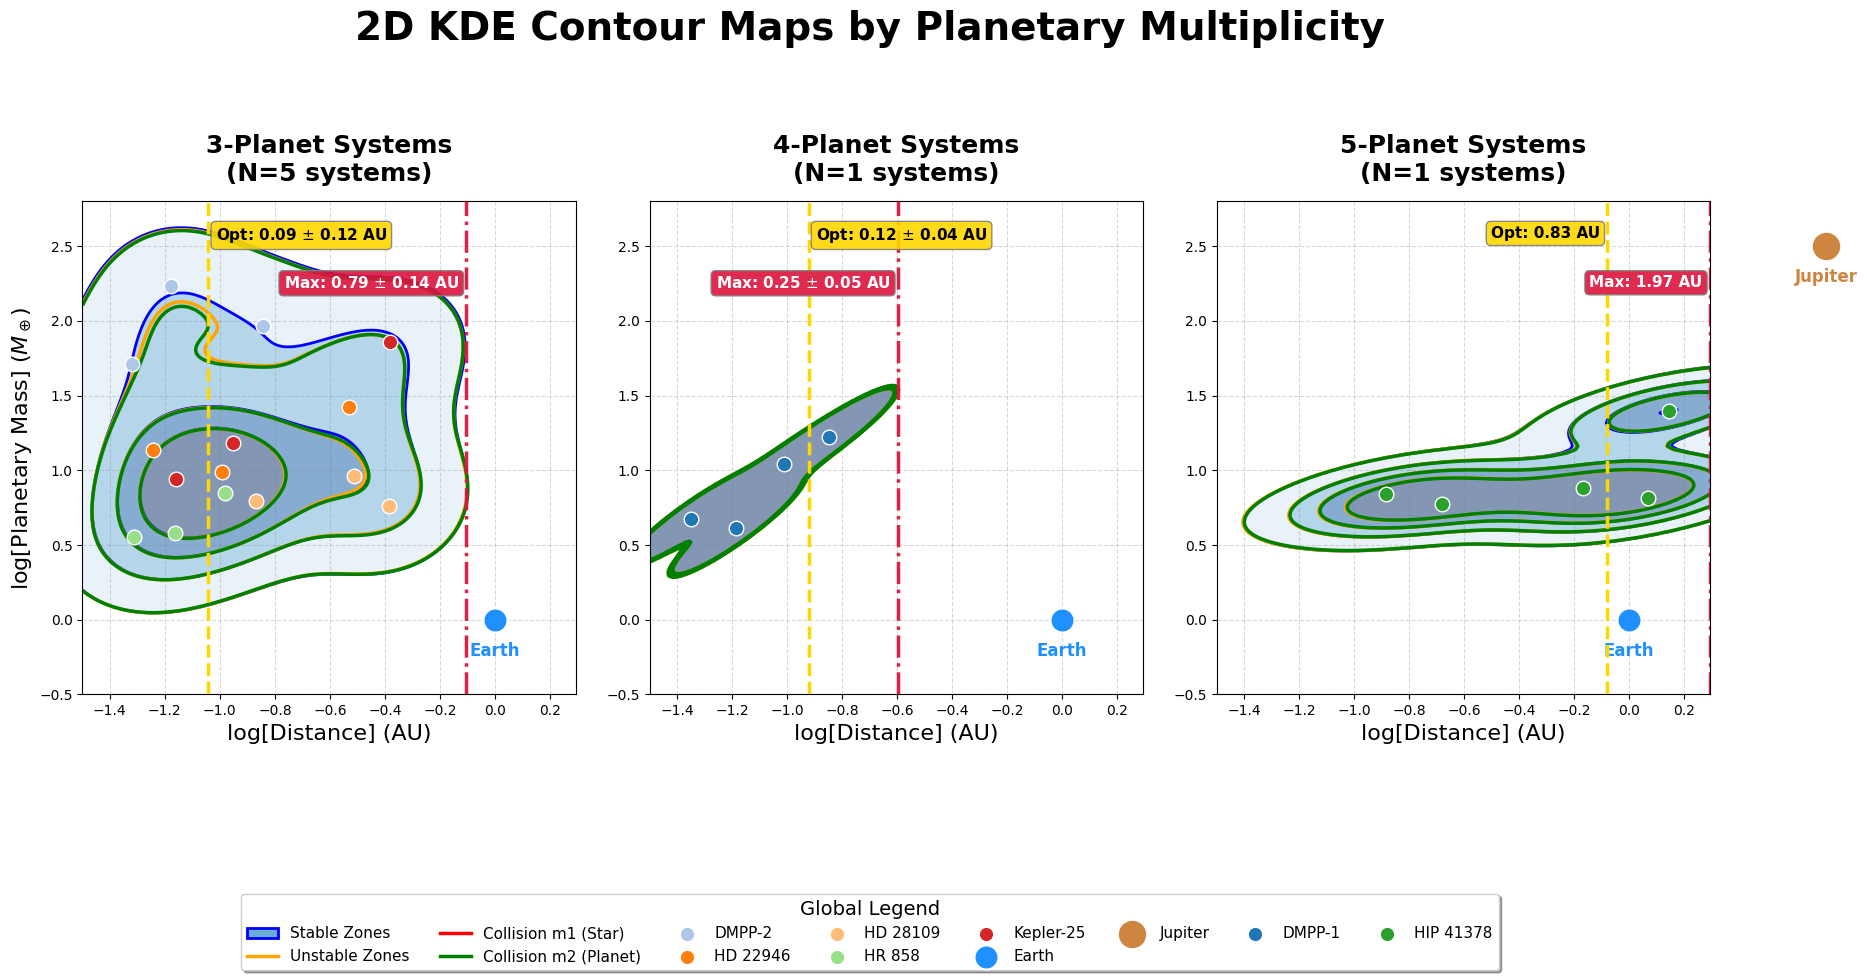


✅ Generación híbrida completada con éxito. Archivos ubicados en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F


In [42]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    print("Esperando selección de carpetas en las ventanas emergentes...")
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
    if not df_datos.empty:
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
        if not df_filtrado.empty:
            print(f"\nSe graficarán {len(df_filtrado)} planetas (sistemas de >= 3 planetas).")
            # CAMBIO AQUÍ: Llamando a la nueva función de agrupamiento
            plot_islands_por_multiplicidad(df_filtrado, DIRECTORIO_RAIZ)
            print("\n✅ Generación híbrida completada con éxito. Archivos ubicados en:", DIRECTORIO_RAIZ)
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")

Esperando selección de carpetas en las ventanas emergentes...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_G (Tipo G)...
✅ Lectura completada. Se extrajeron datos de 124 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Se graficarán 124 planetas (sistemas de >= 3 planetas).

Generando Mapas de Contornos 2D KDE Híbridos por Multiplicidad Planetaria...


Generando paneles 2D híbridos: 100%|██████████| 4/4 [00:01<00:00,  2.67panel/s]



🎯 RESUMEN DE PROBABILIDAD ORBITAL (Zonas Estables)
    3-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.11 ± 0.02 AU | Límite Máximo del Contorno:  11.22 ± 7.68 AU
    4-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.19 ± 0.04 AU | Límite Máximo del Contorno:   4.01 ± 1.43 AU
    5-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.12 ± 0.06 AU | Límite Máximo del Contorno:   4.25 ± 1.93 AU
    6-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.41 ± 0.59 AU | Límite Máximo del Contorno:  22.27 ± 6.83 AU


Gráfico vectorial guardado exitosamente en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_G\Map_2D_KDE_Hybrid_PorMultiplicidad.pdf


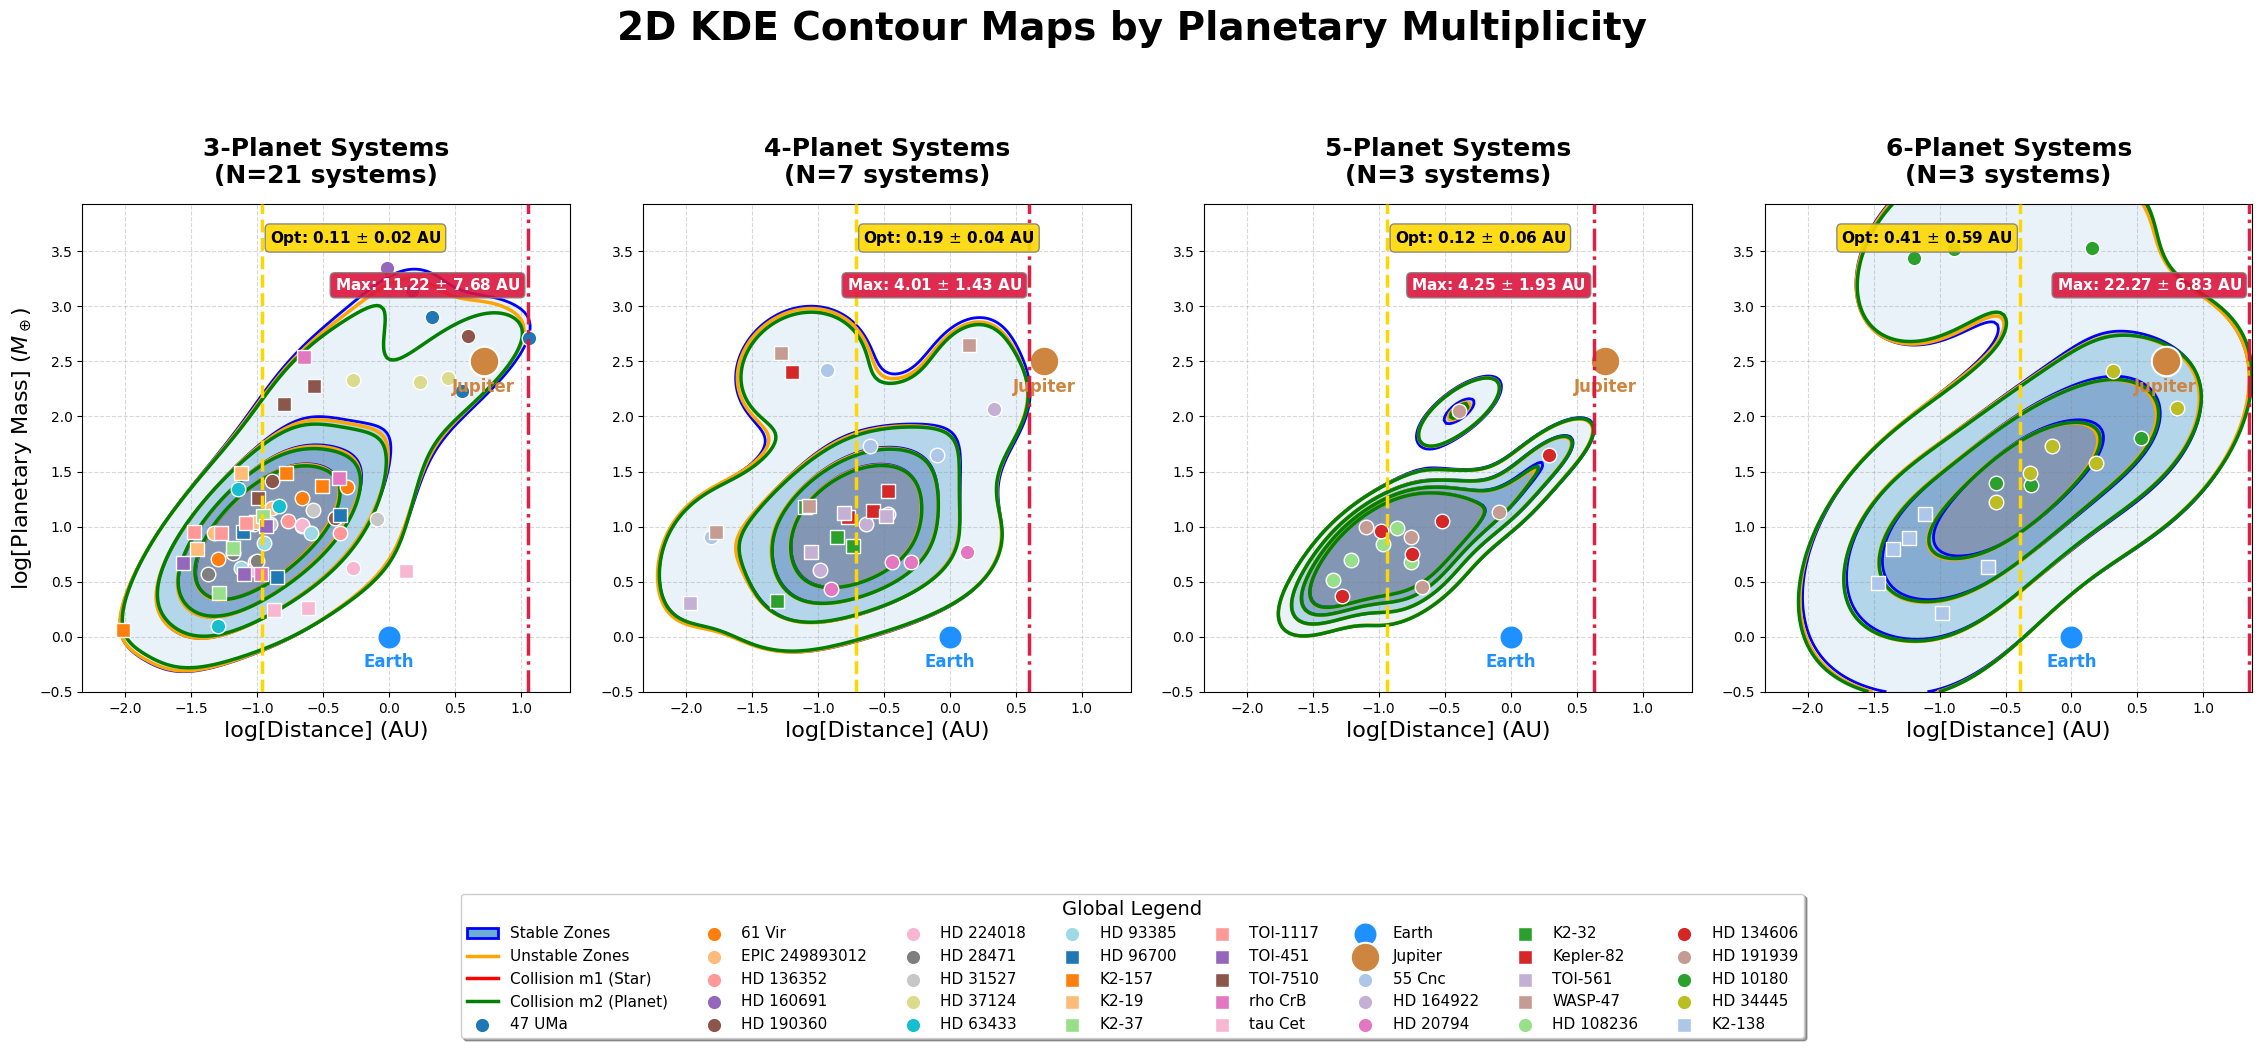


✅ Generación híbrida completada con éxito. Archivos ubicados en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_G


In [43]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    print("Esperando selección de carpetas en las ventanas emergentes...")
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
    if not df_datos.empty:
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
        if not df_filtrado.empty:
            print(f"\nSe graficarán {len(df_filtrado)} planetas (sistemas de >= 3 planetas).")
            # CAMBIO AQUÍ: Llamando a la nueva función de agrupamiento
            plot_islands_por_multiplicidad(df_filtrado, DIRECTORIO_RAIZ)
            print("\n✅ Generación híbrida completada con éxito. Archivos ubicados en:", DIRECTORIO_RAIZ)
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")

Esperando selección de carpetas en las ventanas emergentes...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_K (Tipo K)...
✅ Lectura completada. Se extrajeron datos de 140 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Se graficarán 140 planetas (sistemas de >= 3 planetas).

Generando Mapas de Contornos 2D KDE Híbridos por Multiplicidad Planetaria...


Generando paneles 2D híbridos: 100%|██████████| 4/4 [00:01<00:00,  2.46panel/s]



🎯 RESUMEN DE PROBABILIDAD ORBITAL (Zonas Estables)
    3-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.09 ± 0.02 AU | Límite Máximo del Contorno:   7.21 ± 4.26 AU
    4-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.12 ± 0.02 AU | Límite Máximo del Contorno:   4.07 ± 3.84 AU
    5-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.08 ± 0.02 AU | Límite Máximo del Contorno:   1.50 ± 0.45 AU
    6-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.10 ± 0.05 AU | Límite Máximo del Contorno:   6.56 ± 4.40 AU


Gráfico vectorial guardado exitosamente en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_K\Map_2D_KDE_Hybrid_PorMultiplicidad.pdf


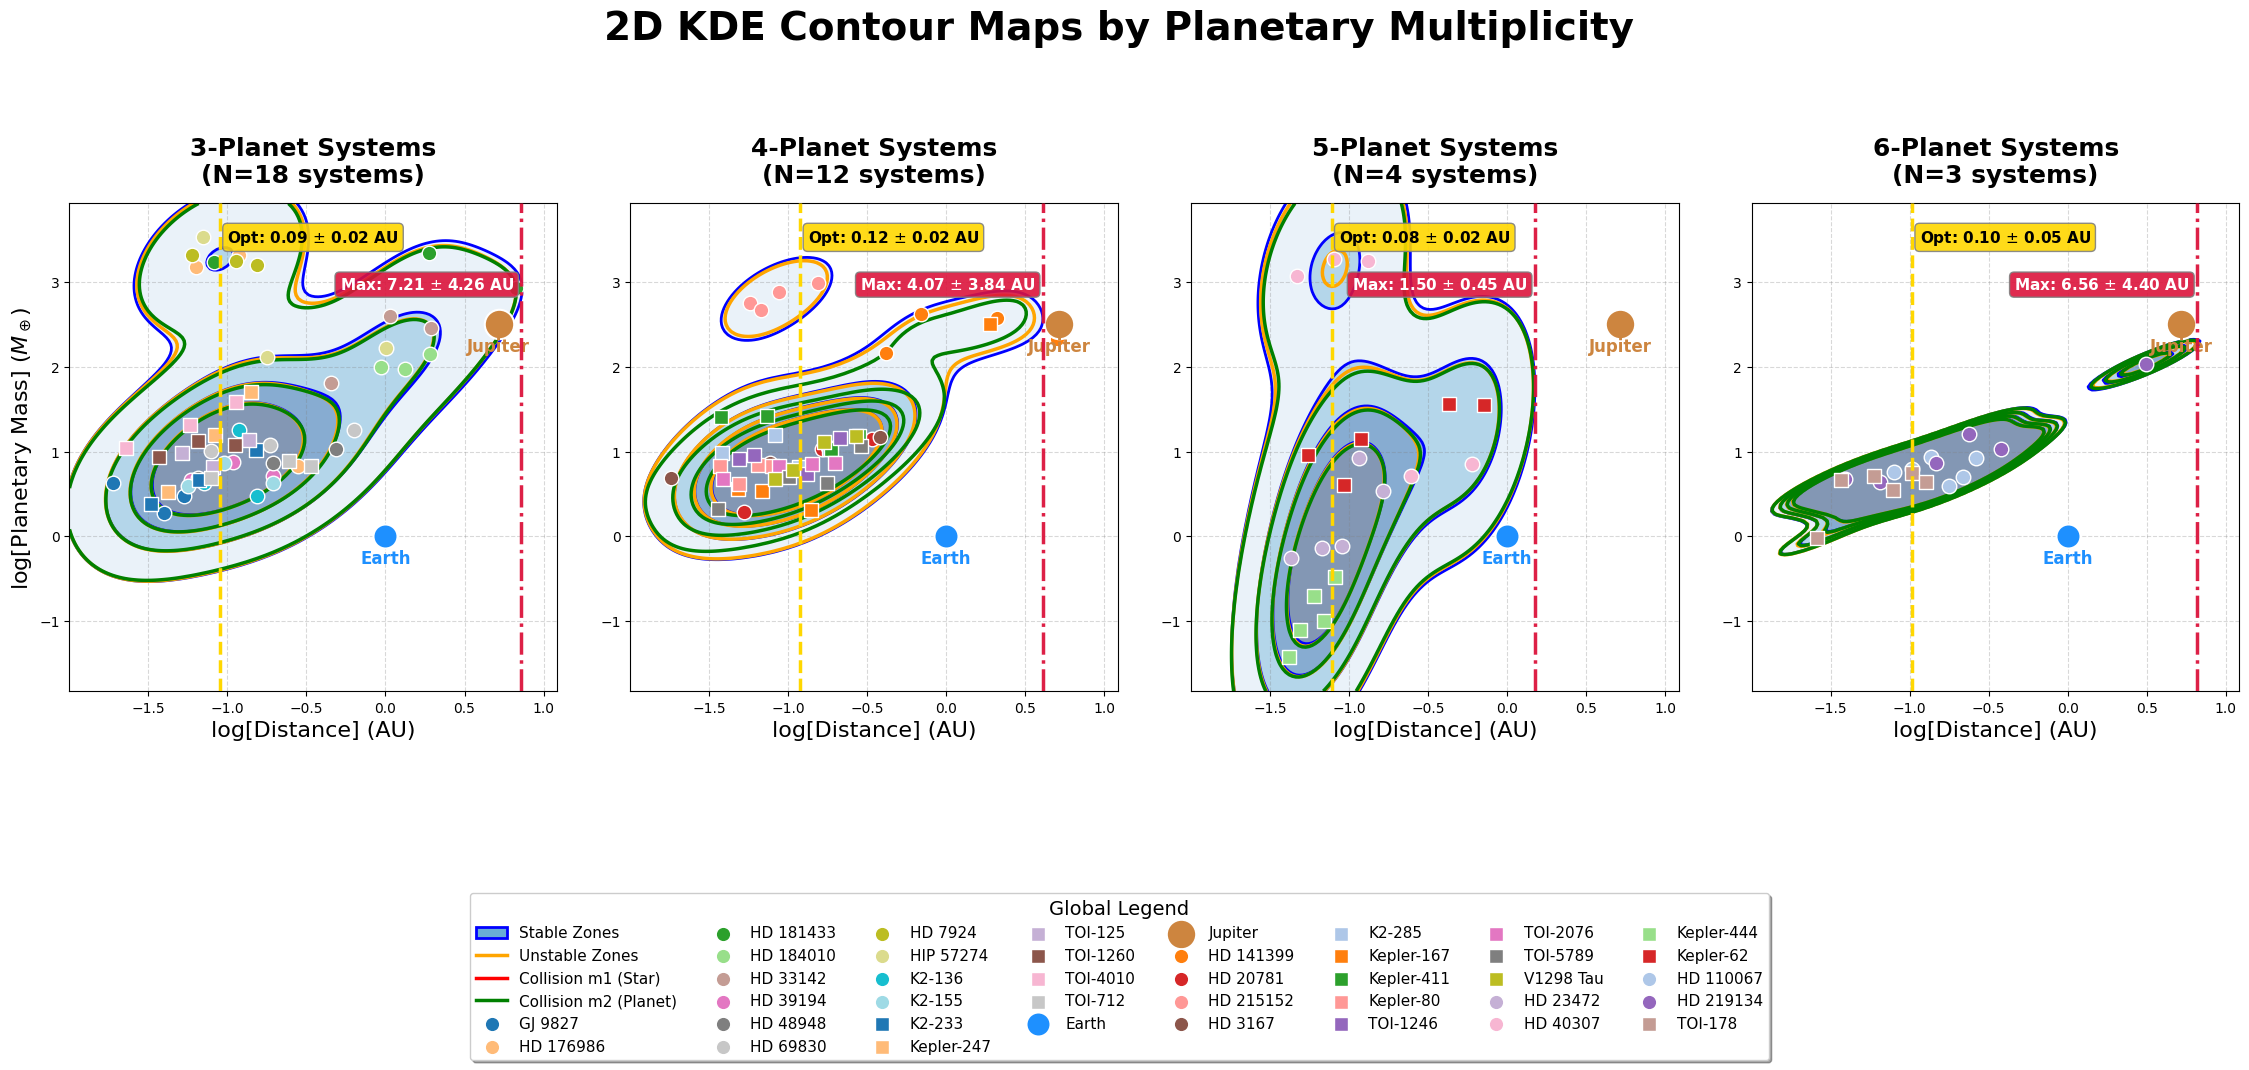


✅ Generación híbrida completada con éxito. Archivos ubicados en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_K


In [44]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    print("Esperando selección de carpetas en las ventanas emergentes...")
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
    if not df_datos.empty:
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
        if not df_filtrado.empty:
            print(f"\nSe graficarán {len(df_filtrado)} planetas (sistemas de >= 3 planetas).")
            # CAMBIO AQUÍ: Llamando a la nueva función de agrupamiento
            plot_islands_por_multiplicidad(df_filtrado, DIRECTORIO_RAIZ)
            print("\n✅ Generación híbrida completada con éxito. Archivos ubicados en:", DIRECTORIO_RAIZ)
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")

Esperando selección de carpetas en las ventanas emergentes...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M (Tipo M)...
✅ Lectura completada. Se extrajeron datos de 160 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(7)]

Se graficarán 160 planetas (sistemas de >= 3 planetas).

Generando Mapas de Contornos 2D KDE Híbridos por Multiplicidad Planetaria...


Generando paneles 2D híbridos: 100%|██████████| 4/4 [00:01<00:00,  2.17panel/s]



🎯 RESUMEN DE PROBABILIDAD ORBITAL (Zonas Estables)
    3-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.06 ± 0.01 AU | Límite Máximo del Contorno:   0.88 ± 0.34 AU
    4-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.10 ± 0.02 AU | Límite Máximo del Contorno:   0.49 ± 0.07 AU
    5-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.11 ± 0.04 AU | Límite Máximo del Contorno:   0.93 ± 0.26 AU
    7-Planet Systems -> Distancia Óptima (Máx. Probabilidad):   0.04 ± 0.02 AU | Límite Máximo del Contorno:   0.12 ± 0.02 AU


Gráfico vectorial guardado exitosamente en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M\Map_2D_KDE_Hybrid_PorMultiplicidad.pdf


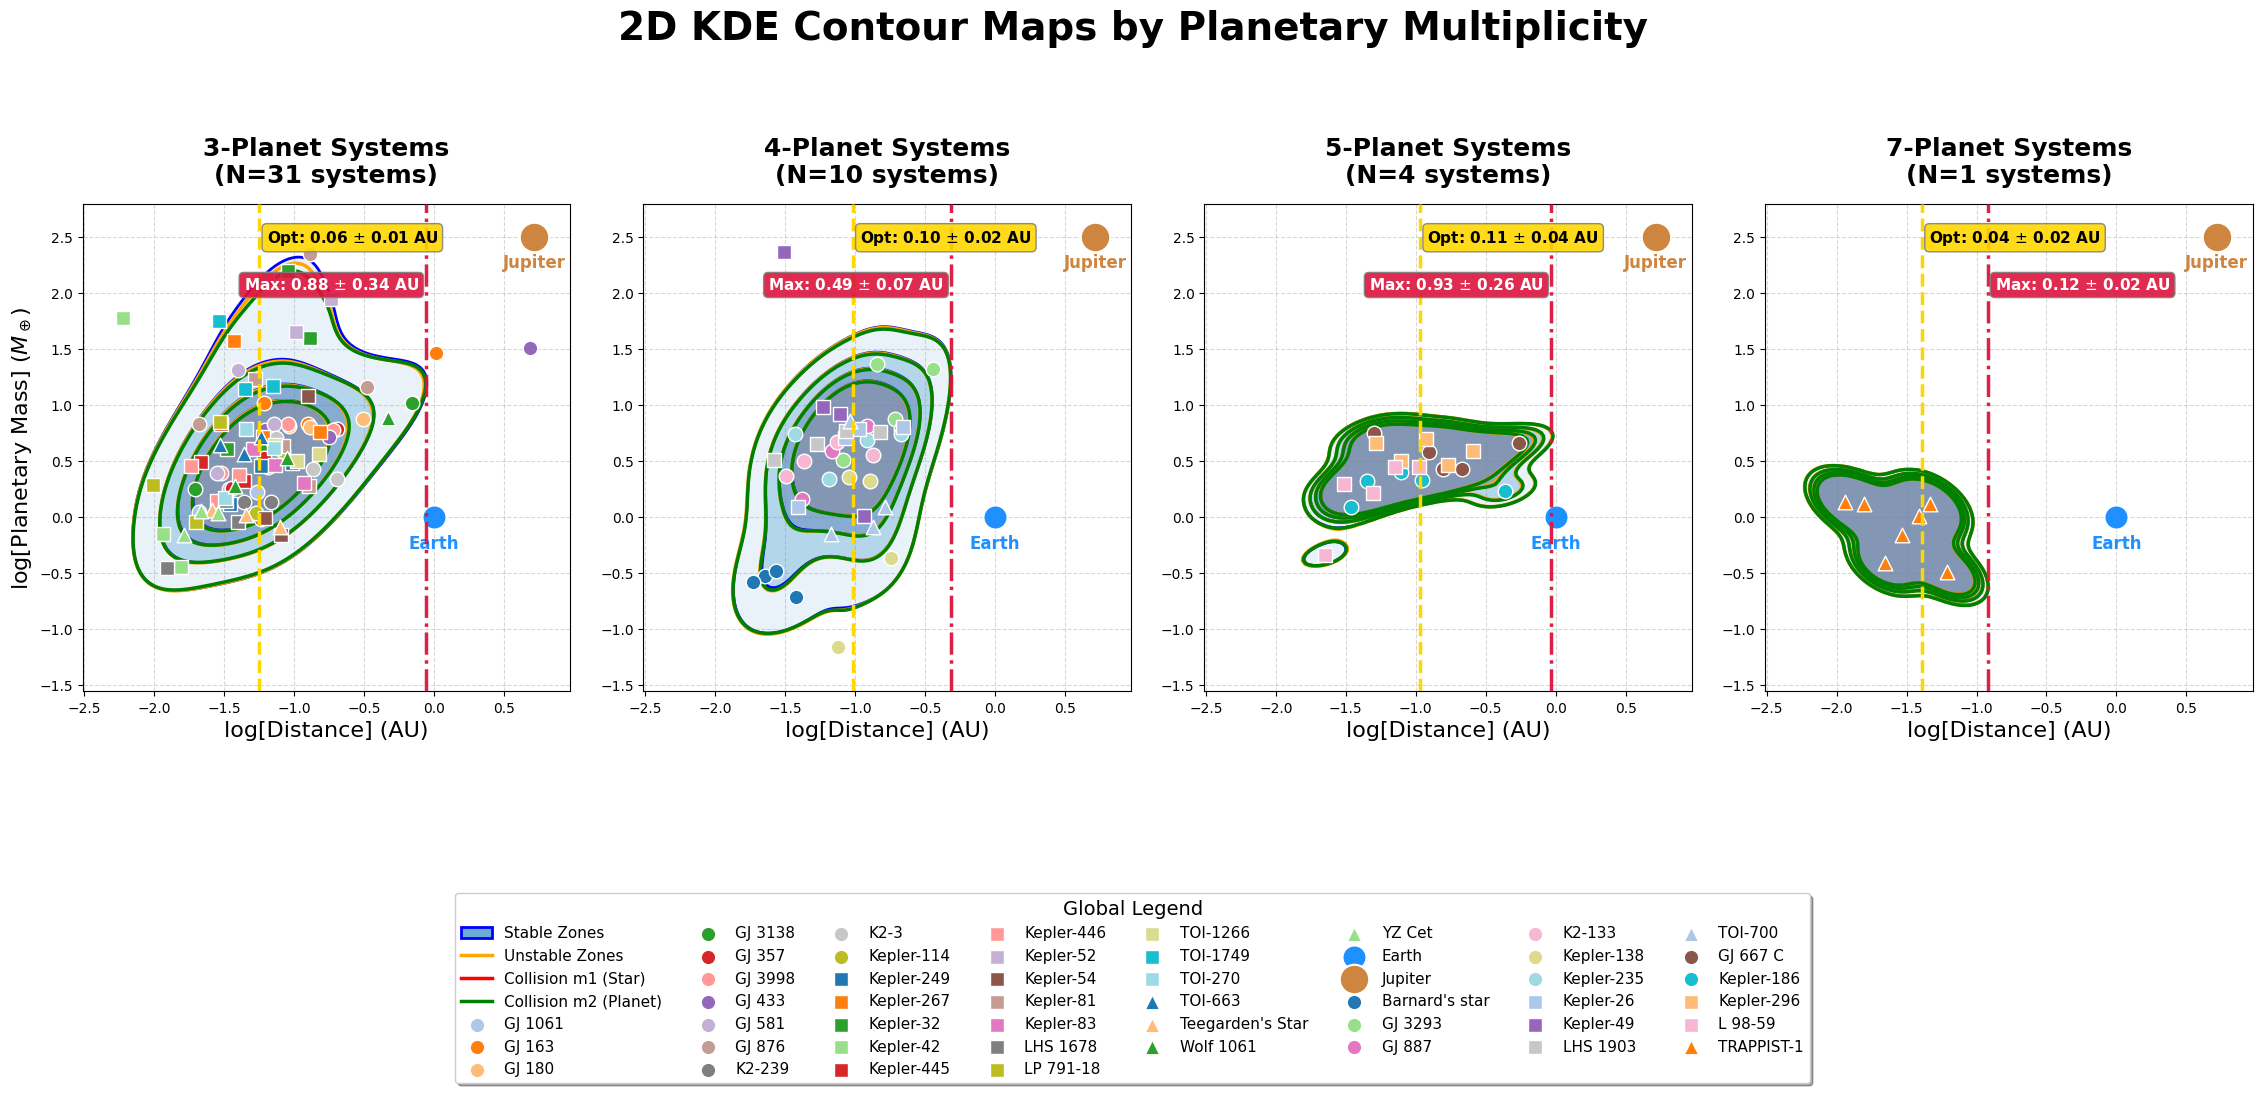


✅ Generación híbrida completada con éxito. Archivos ubicados en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M


In [45]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    print("Esperando selección de carpetas en las ventanas emergentes...")
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
    if not df_datos.empty:
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
        if not df_filtrado.empty:
            print(f"\nSe graficarán {len(df_filtrado)} planetas (sistemas de >= 3 planetas).")
            # CAMBIO AQUÍ: Llamando a la nueva función de agrupamiento
            plot_islands_por_multiplicidad(df_filtrado, DIRECTORIO_RAIZ)
            print("\n✅ Generación híbrida completada con éxito. Archivos ubicados en:", DIRECTORIO_RAIZ)
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")